<a href="https://colab.research.google.com/github/GabrielaTranslite/Sentiment_Analysis_Video_Games/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [49]:
# Reading the reviews file

print(f"File size: {os.path.getsize('steam_reviews_3274580.csv') / 1024:.0f} KB")

reviews = pd.read_csv('steam_reviews_3274580.csv', on_bad_lines='skip')
print(f"No of reviews: {len(reviews)}")


File size: 2356 KB
No of reviews: 5268


In [56]:
reviews.dtypes

review_id                int64
appid                    int64
author_steamid           int64
voted_up                  bool
votes_up                 int64
votes_funny              int64
review_text                str
timestamp_created        int64
publish_date               str
hours_on_record        float64
weighted_vote_score    float64
comment_count            int64
dtype: object

In [57]:
reviews.head()

,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count
0,227214755,3274580,76561198126302244,True,0,0,ok,1780643526,2026-06-05,512.93,0.50000,0
1,227173990,3274580,76561198069792288,True,0,0,I don't understand people. Of course if Ubisof...,1780595391,2026-06-04,59.97,0.50000,0
2,227077952,3274580,76561198389635009,True,0,0,Awesome game! I am looking forward to future c...,1780484019,2026-06-03,4.37,0.50000,0
3,227046650,3274580,76561198060971315,True,1,0,I know this game has been getting mixed review...,1780438119,2026-06-02,33.47,0.52381,0
4,227036499,3274580,76561198032581809,False,6,1,The game seems to just randomly give your city...,1780428223,2026-06-02,23.02,0.57529,0


Since as I discovered later, in the dataset there are some reviews in a different language than English (including Latin), I am adding a language detection step to drop non-English reviews.

In [60]:
from langdetect import detect, LangDetectException
from langdetect import DetectorFactory
DetectorFactory.seed = 42

def get_language(text):
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

reviews['language'] = reviews['review_text'].apply(get_language)
print(reviews['language'].value_counts())

language
en         4628
so          114
unknown      79
de           55
af           40
no           38
tl           35
ro           32
cy           26
es           25
it           24
ca           22
pl           18
tr           18
id           13
da           13
pt           10
fr            9
hu            8
nl            8
sl            8
sk            7
et            6
sw            5
sq            4
hr            4
vi            4
lt            3
zh-cn         3
ru            2
ar            2
th            2
ko            1
fi            1
sv            1
Name: count, dtype: int64


The amount of different languages surprised me, after going through all languages, I decided to remove German, Polish, Chinese, Spanish and Romanian. The last one actually caught some Latin reviews present in the dataset. Some extra Latin reviews were present in Catalan, Portuguese and Italian, I will remove them manually. Langdetect had problems with shorter reviews, but I am going to drop them anyway one of the following steps.

In [94]:


print(reviews[reviews['language'] == 'unknown']['review_text'].head(100))

20          .
26          ,
110      7/10
289      👍👍👍👍
355       NaN
        ...  
4771        !
4851    +++++
5079     9/10
5199     6/10
5201        ‎
Name: review_text, Length: 79, dtype: str


In [104]:
# Dropping certain languages
reviews = reviews[~reviews['language'].isin(['zh-cn', 'de', 'pl', 'es', 'ro'])].copy()

# Dropping rows detected as non-English language
reviews_to_drop = reviews[reviews.index.isin([3565, 4397, 3812, 3820, 4833, 2249, 3994, 5212, 5256, 1687, 204, 715, 2060, 5255])]
print("Dropping the following reviews detected as non-English:")
print(reviews_to_drop[['review_text', 'language']])
reviews = reviews.drop(index=[3565, 4397, 3812, 3820, 4833, 2249, 3994, 5212, 5256, 1687, 204, 715, 2060, 5255])


Dropping the following reviews detected as non-English:
                                            review_text language
204                                   Veni, vidi, vici.       it
715                            Sono pazzi questi romani       it
1687  Akhirnya ada game Ubilembut yang bagus rilis d...       id
2060                              Barbarus ante portas!       pt
2249  Incroyable, pratiquement parfait, je joue en s...       fr
3565  Vini Vidi Vici: J’vais y’aller, j’vais checker...       nl
3812  Komplexná budovateľská stratégia, kde vám čas ...       sk
3820                                        Ave Caesar!       tr
3994  Recensio Anno 117 ab Homine Romano-Celtico (ve...       ca
4397  Anno 117 is precies wat ik hoopte dat het zou ...       nl
4833                          tout bonnement incroyable       fr
5212  Optimus ludus ANNO umquam factus erit; magnus ...       ca
5255  Praeter mutos comites meos, vita mihi, nova ad...       pt
5256                             A

In [105]:
# Removing empty reviews
reviews = reviews[reviews['review_text'].str.strip() != '']

In [106]:
# Checking for NaN values in 'review_text' column
print("NaN values in 'review_text' column:", reviews['review_text'].isna().sum())

NaN values in 'review_text' column: 22


In [107]:
# Dropping reviews with NaN in 'review_text'
reviews = reviews.dropna(subset=['review_text'])


In [109]:
# Number of reviews
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 5098


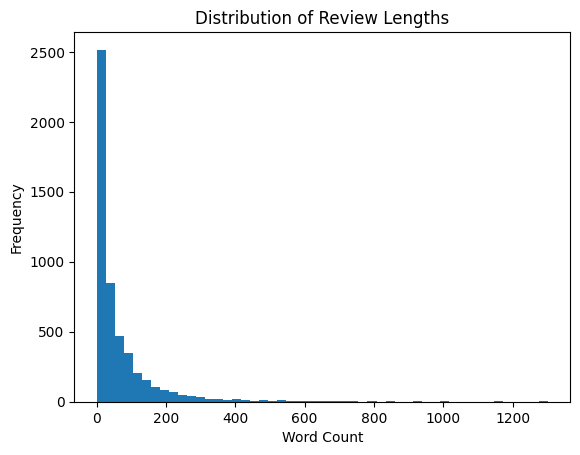

In [110]:
# Review lengths
reviews['word_count'] = reviews['review_text'].str.split().str.len()
plt.hist(reviews['word_count'], bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [111]:
# Removing reviews shorter than 3 words
reviews = reviews[reviews['word_count'] >= 3]

In [113]:
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 4623


In [114]:
# Checking for review_id duplicates in the dataset
reviews.duplicated(subset=['review_id']).sum()

# No duplicates found

np.int64(0)

In [115]:
# Converting columns
reviews['publish_date'] = pd.to_datetime(reviews['publish_date'])
reviews['voted_up'] = reviews['voted_up'].astype(int) # Changing True/False > 1/0
reviews.info()


<class 'pandas.DataFrame'>
Index: 4623 entries, 1 to 5267
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            4623 non-null   int64         
 1   appid                4623 non-null   int64         
 2   author_steamid       4623 non-null   int64         
 3   voted_up             4623 non-null   int64         
 4   votes_up             4623 non-null   int64         
 5   votes_funny          4623 non-null   int64         
 6   review_text          4623 non-null   str           
 7   timestamp_created    4623 non-null   int64         
 8   publish_date         4623 non-null   datetime64[us]
 9   hours_on_record      4623 non-null   float64       
 10  weighted_vote_score  4623 non-null   float64       
 11  comment_count        4623 non-null   int64         
 12  language             4623 non-null   str           
 13  word_count           4623 non-null   int64       

In [119]:
# Checking the min publish dates
reviews['publish_date'].min()

# The first review was published on 2025-11-12, that is on the realese date of the game, so there are no reviews published before the release date.

Timestamp('2025-11-12 00:00:00')

In [120]:
# Distribution of positive and negative reviews
print(reviews['voted_up'].value_counts(normalize=True))

# The dataset is imbalanced, with 63% positive reviews and 37% negative reviews. 
# This may affect the performance of the reference model (logistic regression), so I will need to use techniques to handle the imbalance, such as oversampling the minority class or using class weights in the model.

voted_up
1    0.622972
0    0.377028
Name: proportion, dtype: float64


*Adding patch releases dates*

One of the goals of my analysis is to check how the release of patches and announcements of new content influences the sentiment of players. Therefore I scrapped the necessary data from Anno Pax Romana official website using Claude.

In [122]:
patch_dates = pd.read_csv('anno_117_pax_romana_patches.csv')
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Launch Day,Game released on PC / PS5 / Xbox Series X|S. V...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to fix several causes fo...
2,2025-12-09,1.3 (notes),Patch Notes,Patch 1.3 Notes Published,Official patch notes for version 1.3 published...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and performance issues. ...
4,2026-01-28,1.3.2 (notes),Patch Notes,Patch 1.3.2 Notes Published,Official patch notes for version 1.3.2 publish...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the global deity buff. B...
6,2026-02-18,1.4 (notes),Patch Notes,Patch 1.4 Notes Published,Full patch notes for version 1.4 published
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mosaic Pack (Cosmetic DLC),Patch 1.4 adds support for the Marvellous Mosa...
8,2026-03-04,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with raytracing on consoles...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and Patch 1.5 delayed by...


In [123]:
# Converting patch release dates to datetime
patch_dates['Date'] = pd.to_datetime(patch_dates['Date'])

# Dropping the rows with patch notes publication dates, as they are not relevant for the analysis
patch_dates = patch_dates[~patch_dates['Title'].str.contains('notes', case=False)]
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Launch Day,Game released on PC / PS5 / Xbox Series X|S. V...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to fix several causes fo...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and performance issues. ...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the global deity buff. B...
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mosaic Pack (Cosmetic DLC),Patch 1.4 adds support for the Marvellous Mosa...
8,2026-03-04,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with raytracing on consoles...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and Patch 1.5 delayed by...
11,2026-04-30,1.5,Major Patch + DLC,Patch 1.5 + Prophecies of Ash DLC,First paid DLC for Anno 117: Pax Romana. Adds ...
12,2026-05-01,1.5 Hotfix,Hotfix,Update 1.5 HotFix (PC),PC hotfix released fixing a crash for campaign...
13,2026-05-05,NaN,Announcement,Upcoming Patches - Message from Anno Team,Team acknowledged issues with Update 1.5 launc...


In [124]:
# Adding specific periods between patch releases and announcements to table
reviews['period'] = reviews.apply(lambda row:
    '1.2' if row['publish_date'] < pd.Timestamp('2025-11-18') else
    '1.2 Hotfix' if row['publish_date'] < pd.Timestamp('2025-12-16') else
    '1.3' if row['publish_date'] < pd.Timestamp('2026-01-29') and row['publish_date'] >= pd.Timestamp('2025-12-16') else
    '1.3.2' if row['publish_date'] < pd.Timestamp('2026-02-19') and row['publish_date'] >= pd.Timestamp('2026-01-29') else
    '1.4 + Cosmetic DLC' if row['publish_date'] < pd.Timestamp('2026-03-04') and row['publish_date'] >= pd.Timestamp('2026-02-19') else
    '1.4.1' if row['publish_date'] < pd.Timestamp('2026-04-22') and row['publish_date'] >= pd.Timestamp('2026-03-04') else
    'Release Delay Announced' if row['publish_date'] < pd.Timestamp('2026-04-30') and row['publish_date'] >= pd.Timestamp('2026-04-22') else
    '1.5 + Paid DLC + Hotfix' if row['publish_date'] < pd.Timestamp('2026-05-05') and row['publish_date'] >= pd.Timestamp('2026-04-30') else
    '1.5.1' if row['publish_date'] < pd.Timestamp('2026-05-08') and row['publish_date'] >= pd.Timestamp('2026-05-05') else
    '1.5.2', axis=1)

period_order = [
    '1.2', '1.2 Hotfix', '1.3', '1.3.2',
    '1.4 + Cosmetic DLC', '1.4.1', 'Release Delay Announced',
    '1.5 + Paid DLC + Hotfix', '1.5.1', '1.5.2'
]
reviews['period'] = pd.Categorical(reviews['period'], categories=period_order, ordered=True)

reviews.tail()


,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count,language,word_count,period
5262,209074228,3274580,76561197960711140,1,0,0,Basically poops on the likes of Europa 5 Can't...,1762990994,2025-11-12,0.48,0.469799,0,en,19,1.2
5263,209074198,3274580,76561198041549155,0,0,0,Performance has improved slightly after the Da...,1762990969,2025-11-12,8.00,0.500000,0,en,166,1.2
5264,209074064,3274580,76561198144246893,0,0,0,"Mediocre graphics, art, UI compared to anno 18...",1762990841,2025-11-12,3.73,0.500000,0,en,69,1.2
5266,209072424,3274580,76561199492495065,1,0,0,"Make sure to update nVidia drivers to latest, ...",1762989478,2025-11-12,7.50,0.417803,2,en,152,1.2
5267,209072379,3274580,76561197972252273,1,0,0,GOTY Downsides: - The UI is a lot worse than ...,1762989440,2025-11-12,6.48,0.500000,0,en,69,1.2


In [125]:
# Average score and number of reviews per period
period_summary = reviews.groupby('period').agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
)

print(period_summary) # The distribution is slightly uneven, which may affect the performance of text mining models

                         avg_score  review_count
period                                          
1.2                       0.602587          1701
1.2 Hotfix                0.684146          1621
1.3                       0.595978           547
1.3.2                     0.550725           138
1.4 + Cosmetic DLC        0.425000           120
1.4.1                     0.578182           275
Release Delay Announced   0.578947            38
1.5 + Paid DLC + Hotfix   0.595745            47
1.5.1                     0.684211            19
1.5.2                     0.606838           117


C:\Users\gabri\AppData\Local\Temp\ipykernel_55252\639923896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='period', y='avg_score', data=period_summary, palette='viridis')


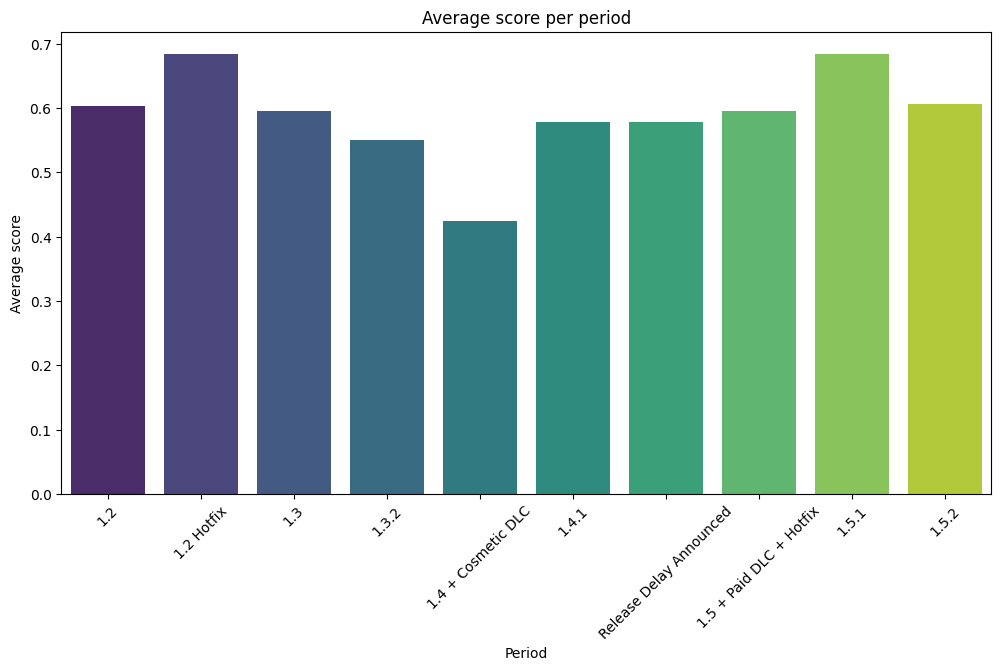

In [126]:
# Chart with average scores per period
plt.figure(figsize=(12, 6))
sns.barplot(x='period', y='avg_score', data=period_summary, palette='viridis')
plt.title('Average score per period')
plt.xlabel('Period')
plt.ylabel('Average score')
plt.xticks(rotation=45)
plt.show()

As we can see from the Steam data, the introduction of Hotfixes and DLCs seem to bring an increase of game scores. Directly after the release, Anno Pax Romana reached an average score of 0.6 which increased to 0.7 after the release of a hotfix. It suggests that there was some initial problem with the game. Hopefully, sentiment analysis will help us discover the exact problem. The average score dropped with time and started to increase back after the release of Cosmetic DLC with patch 1.4. Later, it again increased after the first paid DLC and another hotfix was released.

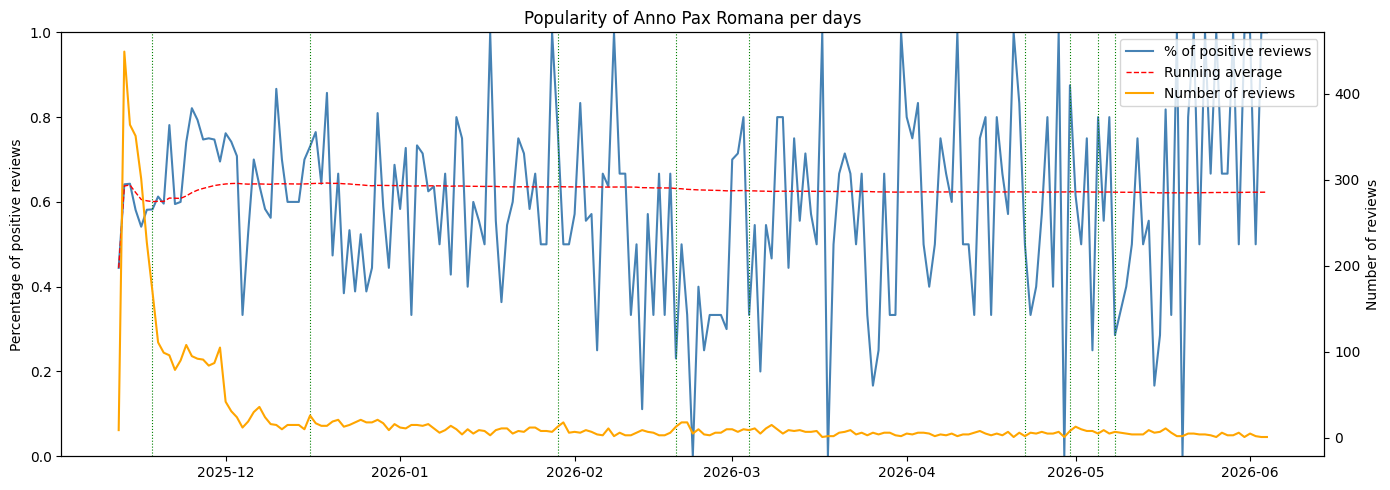

In [127]:
# Score mean and number of reviews per day
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Running (cumulative) average up to each date
daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['review_count'],
         color = 'orange',
         label = 'Number of reviews')
ax2.set_ylabel('Number of reviews')

# Deriving period boundaries from the reviews data (first date of each period except the first)
period_boundaries = (
    reviews.groupby('period', observed=True)['publish_date']
    .min()
    .iloc[1:]
    .values
)

# Running average line
ax1.plot(daily['publish_date'],
         daily['running_avg'],
         color='red', linestyle='--', linewidth=1,
         label='Running average')

# Vertical lines exactly at period boundaries
for d in period_boundaries:
    ax1.axvline(d, color='green', linestyle=':', linewidth=0.8)

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Popularity of Anno Pax Romana per days')
fig.tight_layout()
plt.show()


The chart above shows the number of reviews and percentage of positive reviews. Interestingly, Anno Pax Romana was not a victim of the so called review bombing, despite the less than perfect sentiment towards Ubisoft that is the parent company of the studio releasing the analysed game.

## Sentiment Analysis using VADER algorithm

VADER algorithm was designed to analyze the sentiment of social media texts, therefore it should accurately recognize the sentiment in game reviews. Let's see how successful it will be.

In [128]:
# Definying a cleaning function before analysis

def clean_text(text):
    text = text.lower()                          # small leters
    text = re.sub(r'http\S+', '', text)          # removing links
    text = re.sub(r'[^\w\s]', '', text)          # removing punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # removing multiple spaces
    return text

reviews['clean_text'] = reviews['review_text'].apply(clean_text)

In [129]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
reviews['sentiment_score'] = reviews['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label'] = reviews['sentiment_score'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [130]:
# Checking the results with a classification report

from sklearn.metrics import classification_report

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label']
))

              precision    recall  f1-score   support

           0       0.70      0.51      0.59      1743
           1       0.75      0.87      0.80      2880

    accuracy                           0.73      4623
   macro avg       0.73      0.69      0.70      4623
weighted avg       0.73      0.73      0.72      4623



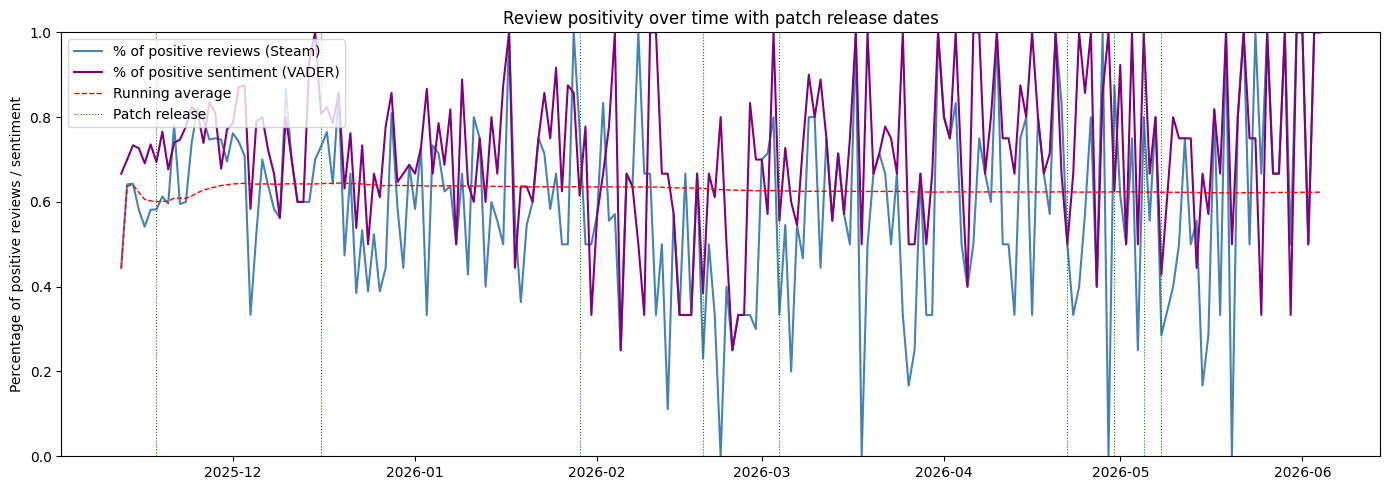

In [131]:
# Chart with patch release dates and VADER sentiment


daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score=('voted_up', 'mean'),
    avg_sentiment=('sentiment_label', 'mean') if 'sentiment_label' in reviews.columns else ('voted_up', 'mean'),
    review_count=('voted_up', 'count')
).reset_index()

daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Deriving period boundaries from the reviews data (first date of each period except the first)
period_boundaries = (
    reviews.groupby('period', observed=True)['publish_date']
    .min()
    .iloc[1:]
    .values
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(daily['publish_date'], daily['avg_score'],
         color='steelblue', label='% of positive reviews (Steam)')
ax1.plot(daily['publish_date'], daily['avg_sentiment'],
         color='purple', label='% of positive sentiment (VADER)')
ax1.plot(daily['publish_date'], daily['running_avg'],
         color='red', linestyle='--', linewidth=1, label='Running average')
ax1.set_ylabel('Percentage of positive reviews / sentiment')
ax1.set_ylim(0, 1)

# Vertical lines exactly at period boundaries
for d in period_boundaries:
    ax1.axvline(d, color='green', linestyle=':', linewidth=0.8)

from matplotlib.lines import Line2D
vline_handle = Line2D([0], [0], color='green', linestyle=':', linewidth=0.8, label='Patch release')
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines + [vline_handle], labels + ['Patch release'], loc='upper left')

plt.title('Review positivity over time with patch release dates')
fig.tight_layout()
plt.show()

Both the classification report and the chart above show that VADER algorithm had some problems with distinguishing the correct sentiment. It's particularly visible in the "positive" peaks in March, April and May of 2026, where we have days with only negative scores from Steam. However, by the end of May, we can also see days where the VADER algorithm have incorrectly classified some positive reviews as negative reviews. The overal score is quite good with accuracy of 73%.

## Lemmatization
Now, I am going to lemmatize the dataset in order to check whether this approach will improve the scores.

In [132]:
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')
reviews['lemmatized_text'] = reviews['clean_text'].apply(
    lambda x: ' '.join(wordnet_lemmatizer.lemmatize(word) for word in x.split())
)

sia_lemmatized = SentimentIntensityAnalyzer()
reviews['sentiment_score_lemmatized'] = reviews['lemmatized_text'].apply(
    lambda x: sia_lemmatized.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label_lemmatized'] = reviews['sentiment_score_lemmatized'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label_lemmatized']
))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


              precision    recall  f1-score   support

           0       0.71      0.50      0.58      1743
           1       0.74      0.87      0.80      2880

    accuracy                           0.73      4623
   macro avg       0.72      0.69      0.69      4623
weighted avg       0.73      0.73      0.72      4623



The overall accuracy score dropped by 0.01 with an identical increase in the recognition of negative reviews. As the further analyzes are less clear after lemmatizaiton, I will continue using the clear_text instead of lemmatized_text.

### Analysis of several incorrectly marked reviews

In [133]:
# Analyzing a sample of incorrectly classified reviews
incorrect = reviews[reviews['voted_up'].astype(int) != reviews['sentiment_label']]
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))

                                            review_text  voted_up  \
2726  It's a decent addition to the Anno series, but...         0   
3213  This needs to be more land based. I don't mean...         0   
4021  Great idea, but still buggy.  Deities are crit...         0   
5013  Its Anno, Ubisoft plays everything so safe. It...         0   
1841  Usage of AI art and unwillingness to disclose ...         0   
758   It's a decent game but it's also just a bit bo...         1   
5123  Not sure what happened.  Every time I blinked ...         1   
3320  In a few years, after we've all paid Ubisoft f...         0   
1812  More potential than Anno 1800, currently worse...         1   
473   Game was all right, pretty limited content on ...         0   

      sentiment_label  
2726                1  
3213                1  
4021                1  
5013                1  
1841                1  
758                 0  
5123                0  
3320                1  
1812                0  


In [134]:
pd.set_option('display.max_colwidth', None)
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        review_text  \
2726                                                                                                                                                                                                                                                           It's a decent addition to the Anno series, but I can’t recommend it due to the reliance on AI-slop. The charm and craftsmanship that defined the earlier titles just aren’t there—this one feels like it’s missing the love and ef

Interestingly, it turns out that the sentiment analysis can sometimes be more truthful than the actual player score. Reviews no. 758 and 1812 show that the reviewers gave the game a vote up, but wrote a negative review. In turn, review no. 3213 is a list of wishes, so the algorithm didn't have clear signal. Similarly, reviews 3320 and 5123 were equally problematic due to use of sarcasm and idiomatic expressions that are difficult to evaluate by the alogirthm.
Reviews 2726 and 4021 might give the algorithm mixed signals due to "compliement" + "but" structure.

## Using TF-IDF Analysis and Wordclouds for Top Terms Discovery

In [ ]:
# TF-IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Defining custom stop words list by adding game-specific terms to the default English stop words
custom_stops = list(ENGLISH_STOP_WORDS) + ['anno', '1800', 'game', 'games', 'like', 'just', 'really', 'im', 'dont']

vec = TfidfVectorizer(stop_words=custom_stops, max_features=5000)
X = vec.fit_transform(reviews['clean_text'])

# Creating masks for positive and negative reviews (.values → numpy array, required for sparse indexing)
pos_mask = (reviews['voted_up'] == 1).values
neg_mask = (reviews['voted_up'] == 0).values

# Mean TF-IDF scores for each term in positive and negative reviews
mean_pos = np.asarray(X[pos_mask].mean(axis=0)).flatten()
mean_neg = np.asarray(X[neg_mask].mean(axis=0)).flatten()

terms = vec.get_feature_names_out()

# Top terms characteristic for positive reviews
top_pos = sorted(zip(terms, mean_pos), key=lambda x: x[1], reverse=True)[:20]
print("Top terms for positive reviews:")
for term, score in top_pos:
    print(f"{term}: {score}")




Top terms for positive reviews:
good: 0.04941154291308922
great: 0.04765870095879307
fun: 0.03131952225647169
love: 0.027778523851444515
city: 0.024695032835713525
far: 0.023763513678627574
new: 0.022165293520534535
best: 0.02123949905595439
time: 0.019497175604013633
play: 0.017689882036315864
series: 0.01747301690882565
campaign: 0.01681032623219059
better: 0.016801132942767742
roman: 0.016526191637804596
hours: 0.01611342738592046
building: 0.014937316078033783
played: 0.014576543967254994
builder: 0.014559253466405046
beautiful: 0.01375383412463779
nice: 0.013349938358809113


According to the TF-IDF analysis, it seems that Anno Pax Romana is seen as good or even great game by reviewers that gave it a vote up. It is also praised by the campaign, beautiful graphic, hours of play and the city building possibilities, which are characteristic for Anno series.

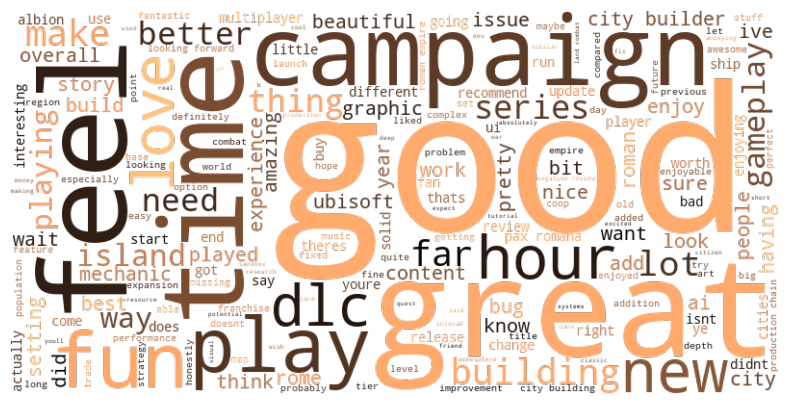

In [143]:
# Generating a WordCloud for positive reviews

from wordcloud import WordCloud
positive_text = ' '.join(reviews[reviews['voted_up'] == 1]['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color=None,
                      mode='RGBA',
                      stopwords=set(custom_stops),
                      colormap='copper').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [145]:
# Top terms characteristic for negative reviews
top_neg = sorted(zip(terms, mean_neg), key=lambda x: x[1], reverse=True)[:20]
print("\nTop terms for negative reviews:")
for term, score in top_neg:
    print(f"{term}: {score}")


Top terms for negative reviews:
ubisoft: 0.03645436179589777
ai: 0.028146844941181033
multiplayer: 0.02683632841182271
campaign: 0.02643205784629388
play: 0.02525212719192431
feels: 0.019772037963733197
time: 0.016651396397541606
bad: 0.01564196730836149
better: 0.015250848183692906
good: 0.015148170518014325
buy: 0.01514493457703663
hours: 0.015068164338932629
doesnt: 0.014218735702635465
release: 0.013456221295898123
connect: 0.013319428329311718
unfinished: 0.013218169349748695
work: 0.01314054883343538
fix: 0.01311217142136563
dlc: 0.013001027296170213
bugs: 0.012724248264857404


In turn, reviews that do not recommend the game have mainly negative connotations with Ubisoft company, which has admittedly bad press due to several failures of their previous titles, such as Assassin's Creed Shadows, cancellation of Prince of Persia: The Sands of Time remake, mass layoffs and studio closures.
The presence of AI in negative reviews is also important insight for the game developers. It seems that players value human creativity and are unhappy with AI creations in the game, even if they speed up the development.
The third important aspect influencing negative opinion is the multiplayer mode which seemed to not work correctly at the time of release.

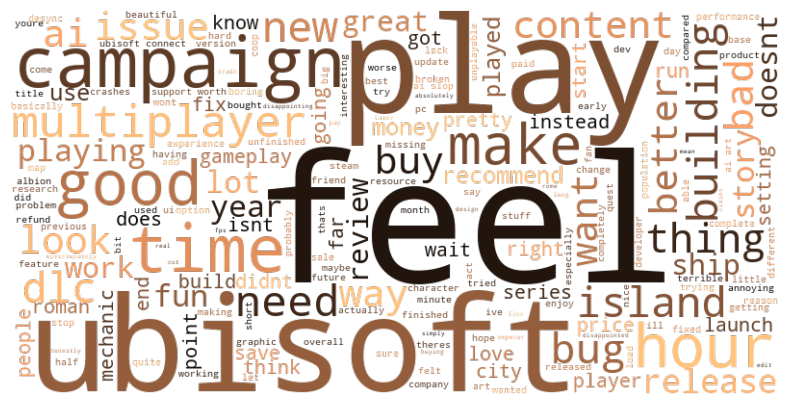

In [148]:
# Generating word clouds for negative reviews
negative_text = ' '.join(reviews[reviews['voted_up'] == 0]['clean_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color=None,
                      mode='RGBA',
                      stopwords=set(custom_stops),
                      colormap='copper').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.show()

## Analyzing key phrases in negative reviews using KeyBERT algorithm

In [ ]:
# Analyzing key phrases in negative reviews using KeyBERT 
# with a custom stop words list and grouped by periods to see if there are differences in key phrases mentioned in negative reviews across different periods of the game's lifecycle.

from keybert import KeyBERT

kw_model = KeyBERT()

# Joining all negative reviews into one text for key phrase extraction
neg_text = " ".join(reviews[reviews['voted_up'] == 0]['clean_text'].dropna().tolist())

keywords = kw_model.extract_keywords(
    neg_text,
    keyphrase_ngram_range=(2, 4),
    stop_words="english",
    top_n=40
)
for phrase, score in keywords:
    print(f"{score:.3f}  {phrase}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\gabri\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [73]:
# LDA topic modeling on all reviews

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vec = CountVectorizer(ngram_range=(1, 1), stop_words="english",
                      max_features=3000, min_df=10)
X = vec.fit_transform(reviews['clean_text'].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

feature_names = vec.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: game, 1800, anno, just, like, dlc, new, campaign, content, good
Topics 2: game, campaign, like, just, anno, feels, performance, hours, story, settings
Topics 3: anno, game, 1800, like, city, great, really, new, roman, good
Topics 4: game, ai, like, dont, art, just, ubisoft, anno, people, im
Topics 5: game, ubisoft, multiplayer, play, good, bugs, anno, issues, connect, time


In [74]:
# LDA topic modeling on positive reviews

vec_pos = CountVectorizer(ngram_range=(1, 1), stop_words="english", max_features=3000, min_df=10)
X_pos = vec_pos.fit_transform(reviews[reviews['voted_up'] == 1]['clean_text'].dropna())
lda_pos = LatentDirichletAllocation(n_components=5, random_state=42)
lda_pos.fit(X_pos) 
feature_names_pos = vec_pos.get_feature_names_out()
for i, topic in enumerate(lda_pos.components_):
    top_words = [feature_names_pos[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: anno, game, 1800, great, new, campaign, like, 117, series, good
Topics 2: city, game, roman, anno, builder, pax, romana, building, empire, 117
Topics 3: game, like, just, anno, really, 1800, building, buildings, production, build
Topics 4: game, good, just, ubisoft, play, like, im, dont, great, ai
Topics 5: anno, game, 1800, good, like, love, far, fun, better, best


In [75]:
# LDA topic modeling on negative reviews
vec_neg = CountVectorizer(ngram_range=(1, 1), stop_words="english", max_features=3000, min_df=10)
X_neg = vec_neg.fit_transform(reviews[reviews['voted_up'] == 0]['clean_text'].dropna())
lda_neg = LatentDirichletAllocation(n_components=5, random_state=42)
lda_neg.fit(X_neg)
feature_names_neg = vec_neg.get_feature_names_out()
for i, topic in enumerate(lda_neg.components_):
    top_words = [feature_names_neg[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: game, ubisoft, dlc, pass, year, release, content, paid, buy, edition
Topics 2: ai, game, anno, art, 1800, ubisoft, like, dont, slop, campaign
Topics 3: game, ubisoft, play, multiplayer, just, time, connect, hours, issues, work
Topics 4: game, anno, build, need, city, like, time, fps, settings, trade
Topics 5: game, anno, 1800, like, just, campaign, feels, really, new, feel


## Top keywords in negative reviews per patch period

In [150]:
# Top 10 TF-IDF keywords in negative reviews per patch period
# TF-IDF is fit on ALL negative reviews so the vocabulary is shared across periods,
# making scores directly comparable column-to-column.

TOP_N = 10
MIN_REVIEWS = 5  # skip periods with too few negative reviews

neg = reviews[reviews['voted_up'] == 0].copy()

vec_per = TfidfVectorizer(stop_words=custom_stops, max_features=5000)
X_per = vec_per.fit_transform(neg['clean_text'])
terms_per = vec_per.get_feature_names_out()

results = {}
for period in neg['period'].cat.categories:
    mask = (neg['period'] == period).values
    if mask.sum() < MIN_REVIEWS:
        continue
    mean_scores = np.asarray(X_per[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:TOP_N]
    results[str(period)] = [terms_per[i] for i in top_idx]

keyword_table = pd.DataFrame(results, index=range(1, TOP_N + 1))
keyword_table.index.name = 'Rank'

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 20)
keyword_table


,1.2,1.2 Hotfix,1.3,1.3.2,1.4 + Cosmetic DLC,1.4.1,Release Delay Announced,1.5 + Paid DLC + Hotfix,1.5.1,1.5.2
Rank,,,,,,,,,,
1,ai,campaign,campaign,finished,pass,ubisoft,pain,buy,trajan,ubisoft
2,ubisoft,ai,play,campaign,dlc,better,incomplete,ubisoft,requires,play
3,multiplayer,ubisoft,multiplayer,content,year,hours,censoring,play,year,connect
4,play,play,ubisoft,ubisoft,release,dlc,aspects,generated,work,instead
5,campaign,multiplayer,hours,boring,season,boring,bother,compared,error,time
6,good,feels,fun,gets,paid,feels,surprising,dlc,corporate,steam
7,desync,time,feels,isnt,content,content,build,fixed,original,paid
8,connect,bugs,time,close,years,pass,year,assets,order,mechanics
9,art,way,better,recommend,ubisoft,buy,buy,better,alert,fun


### KeyBERT key phrases in negative reviews per patch period